# Stage 1 Feature Analysis & Selection

This notebook covers the feature-engineering and feature-selection story for Chapter 5:
where the 16 candidate features come from, how the synthetic dataset that trains the
classifier is put together, how each feature actually separates Valid from Invalid
curves, and how we go from 16 candidates down to a final trained set.

Structure:
1. Load the data
2. The synthetic curve generator (composition, example curves)
3. The 16 candidate features, in four groups
4. How each feature separates Valid from Invalid (distributions + tests)
5. Correlation among the 16
6. Cross-validated feature ranking
7. Final comparison: Full set vs Top 8 vs Top 10 vs a greedy-selected subset


In [22]:
import importlib
import sys
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance
from sklearn.metrics import balanced_accuracy_score, f1_score, roc_auc_score


def ensure_local_growthqa():
    cwd = Path.cwd().resolve()
    for candidate in [cwd, cwd.parent, cwd.parent.parent]:
        src_candidate = candidate / "src"
        module_path = src_candidate / "growthqa" / "classifier" / "train_from_meta.py"
        if module_path.exists():
            if str(src_candidate) not in sys.path:
                sys.path.insert(0, str(src_candidate))
            return src_candidate
    return None

SRC_ROOT = ensure_local_growthqa()
if SRC_ROOT is None:
    raise RuntimeError("Could not locate the local src directory for growthqa")

sys.modules.pop("growthqa.classifier.train_from_meta", None)
importlib.invalidate_caches()
train_from_meta = importlib.import_module("growthqa.classifier.train_from_meta")
train_from_meta = importlib.reload(train_from_meta)

from growthqa.classifier.train_from_meta import (
    build_model_matrix, build_models, STAGE1_FEATURE_GROUPS, STAGE1_CANDIDATE_POOL, train_from_meta_csv
)

sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Using src root:", SRC_ROOT)
print("Loaded module:", train_from_meta.__file__)


Using src root: C:\Users\prern\Downloads\ThesisFinal\curveql\src
Loaded module: C:\Users\prern\Downloads\ThesisFinal\curveql\src\growthqa\classifier\train_from_meta.py


In [23]:
# ---- Configuration ----
N_CV_FOLDS = 5
RF_N_ESTIMATORS = 200          # used for the final permutation-importance ranking
RF_PROXY_N_ESTIMATORS = 80     # lighter model reused inside the greedy search loop
GREEDY_MAX_STEPS = 10
GREEDY_PLATEAU_GAIN = 0.003


## 1. Load the data

`training_meta.csv` is produced by `build-train-meta` from the synthetic wide file and
the lab wide file together (see `build_meta_dataset.run_merge_preprocess_meta`). It
already carries every candidate feature computed the same way for training and
inference.


In [3]:
META_CSV = Path("../data/train_data/training_meta.csv")
meta = pd.read_csv(META_CSV)

print("Rows:", meta.shape[0], "| base curves:", meta["base_curve_id"].nunique())
print("Label balance:", meta["Is_Valid"].value_counts().rename({1: "Valid", 0: "Invalid"}).to_dict())
print("Source split:", meta["source_type"].value_counts().to_dict())


Rows: 2976 | base curves: 992
Label balance: {'Valid': 1785, 'Invalid': 1191}
Source split: {'synthetic': 2700, 'lab': 276}


## 2. The synthetic curve generator

Most of the training data (2700 of the 2976 rows here) comes from
`growthqa.synthetic.timeseries_curve_data`, not from real lab measurements. It builds a
fixed, reproducible composition of curves rather than randomly sampling an unspecified
mixture, so the exact makeup of the dataset can be reported plainly.

Four **valid** subtypes (plain, fast, late, decline) and seven **invalid** subtypes
(obvious, diauxic, subtle, nearreal, decline_only, noise, nogrowth) are generated in
fixed counts. A fraction of the valid curves also get missing readings or negative
outliers injected, so the valid class isn't uniformly clean -- it includes curves a
classifier genuinely has to work to recognize as valid.


In [4]:
wide_synth = pd.read_csv("../data/pipeline_data/timeseries_wide_SD1.csv")

composition = (
    wide_synth.groupby(["Is_Valid", "Curve Subtype"]).size()
    .rename("count").reset_index()
    .sort_values(["Is_Valid", "count"], ascending=[False, False])
)
composition["Is_Valid"] = composition["Is_Valid"].map({True: "Valid", False: "Invalid"})
composition


,Is_Valid,Curve Subtype,count
10,Valid,plain,203
7,Valid,decline,100
8,Valid,fast,100
9,Valid,late,100
5,Invalid,obvious,80
1,Invalid,diauxic,60
6,Invalid,subtle,60
0,Invalid,decline_only,55
2,Invalid,nearreal,55
4,Invalid,noise,45


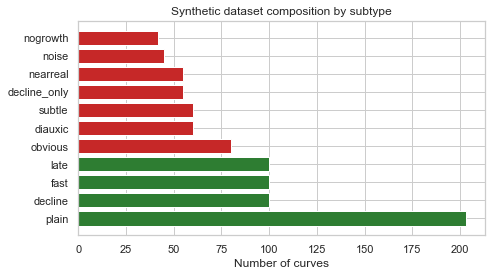

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
order = composition.sort_values("count", ascending=False)
colors = ["#2e7d32" if v == "Valid" else "#c62828" for v in order["Is_Valid"]]
ax.barh(order["Curve Subtype"], order["count"], color=colors)
ax.set_xlabel("Number of curves")
ax.set_title("Synthetic dataset composition by subtype")
plt.tight_layout()
plt.show()


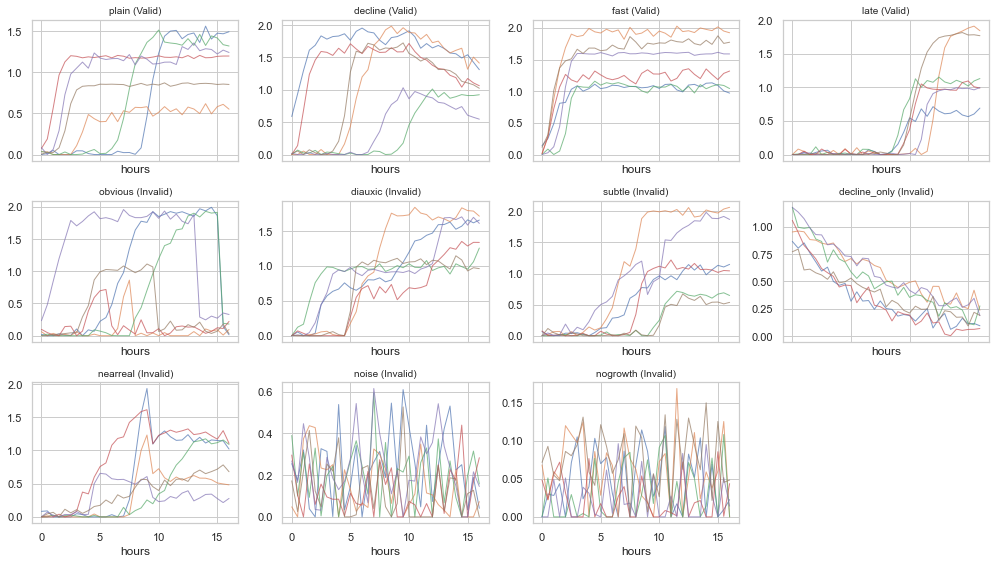

In [6]:
from growthqa.preprocess.timegrid import get_sorted_time_columns, parse_time_from_header

time_cols = get_sorted_time_columns(wide_synth)
t_vals = [parse_time_from_header(c) for c in time_cols]

subtypes = composition["Curve Subtype"].tolist()
fig, axes = plt.subplots(3, 4, figsize=(14, 8), sharex=True)
for ax, subtype in zip(axes.flat, subtypes):
    sub = wide_synth[wide_synth["Curve Subtype"] == subtype]
    sample = sub.sample(min(6, len(sub)), random_state=42)
    for _, row in sample.iterrows():
        ax.plot(t_vals, row[time_cols].values, alpha=0.7, linewidth=1)
    is_valid = sub["Is_Valid"].iloc[0]
    ax.set_title(f"{subtype} ({'Valid' if is_valid else 'Invalid'})", fontsize=10)
    ax.set_xlabel("hours")
for ax in axes.flat[len(subtypes):]:
    ax.axis("off")
plt.tight_layout()
plt.show()


## 3. The 16 candidate features, in four groups

Rather than throwing every computable curve statistic at the classifier, the candidate
pool is organized around four questions, each covering a failure mode the others don't:

- **Observation quality** -- can we even trust the shape we're about to measure?
- **Level** -- where did it start and end?
- **Growth dynamics** -- how did it get from start to end?
- **Shape integrity** -- does the trajectory look like real growth, or an artifact?

This is imported directly from `train_from_meta.STAGE1_FEATURE_GROUPS`, so the notebook
and the production code can never drift apart on what the candidate pool actually is.


In [7]:
for group, feats in STAGE1_FEATURE_GROUPS.items():
    print(f"{group} ({len(feats)}): {feats}")
print()
print("Total candidate features:", len(STAGE1_CANDIDATE_POOL))


observation_quality (4): ['observed_tmax', 'n_points_observed', 'max_gap_hours', 'missing_frac_on_grid']
level (2): ['initial_OD', 'final_OD']
growth_dynamics (5): ['net_change_per_hour', 'max_slope', 'auc_per_hour', 'lag_time_est', 'growth_phase_duration']
shape_integrity (5): ['monotonicity_fraction', 'largest_drop_frac', 'multi_phase_flag', 'roughness', 'noise_residual_std']

Total candidate features: 16


## 4. How each feature separates Valid from Invalid

For each feature: a distribution split by label, a Mann-Whitney U test (curves aren't
normally distributed, so a rank-based test is more appropriate than a t-test), and the
AUC you'd get from using that single feature alone as a classifier -- an intuitive
separability score where 0.5 is random and 1.0 is perfect separation.


In [8]:
X_all, y_all, groups_all, feature_cols_all, eval_df_all = build_model_matrix(meta, label_col="Is_Valid")
X16 = X_all[STAGE1_CANDIDATE_POOL].copy()

rows = []
for feat in STAGE1_CANDIDATE_POOL:
    valid_vals = X16.loc[y_all == 1, feat].dropna()
    invalid_vals = X16.loc[y_all == 0, feat].dropna()
    u_stat, p_val = stats.mannwhitneyu(valid_vals, invalid_vals, alternative="two-sided")
    # AUC of the raw feature value as a single-feature classifier
    filled = X16[feat].fillna(X16[feat].median())
    auc_single = roc_auc_score(y_all, filled)
    auc_single = max(auc_single, 1 - auc_single)  # direction-agnostic separability
    rows.append({"feature": feat, "mannwhitney_p": p_val, "single_feature_auc": auc_single})

separability = pd.DataFrame(rows).sort_values("single_feature_auc", ascending=False).reset_index(drop=True)
separability


,feature,mannwhitney_p,single_feature_auc
0,largest_drop_frac,2.022687e-196,0.824921
1,final_OD,6.878672e-136,0.764106
2,net_change_per_hour,6.141560e-115,0.746144
3,monotonicity_fraction,2.199325e-66,0.685794
4,initial_OD,1.385226e-61,0.675807
5,roughness,1.580343e-53,0.666383
6,multi_phase_flag,3.766893e-53,0.591223
7,growth_phase_duration,1.003125e-14,0.590291
8,noise_residual_std,4.942686e-14,0.581380
9,lag_time_est,6.102683e-11,0.569725


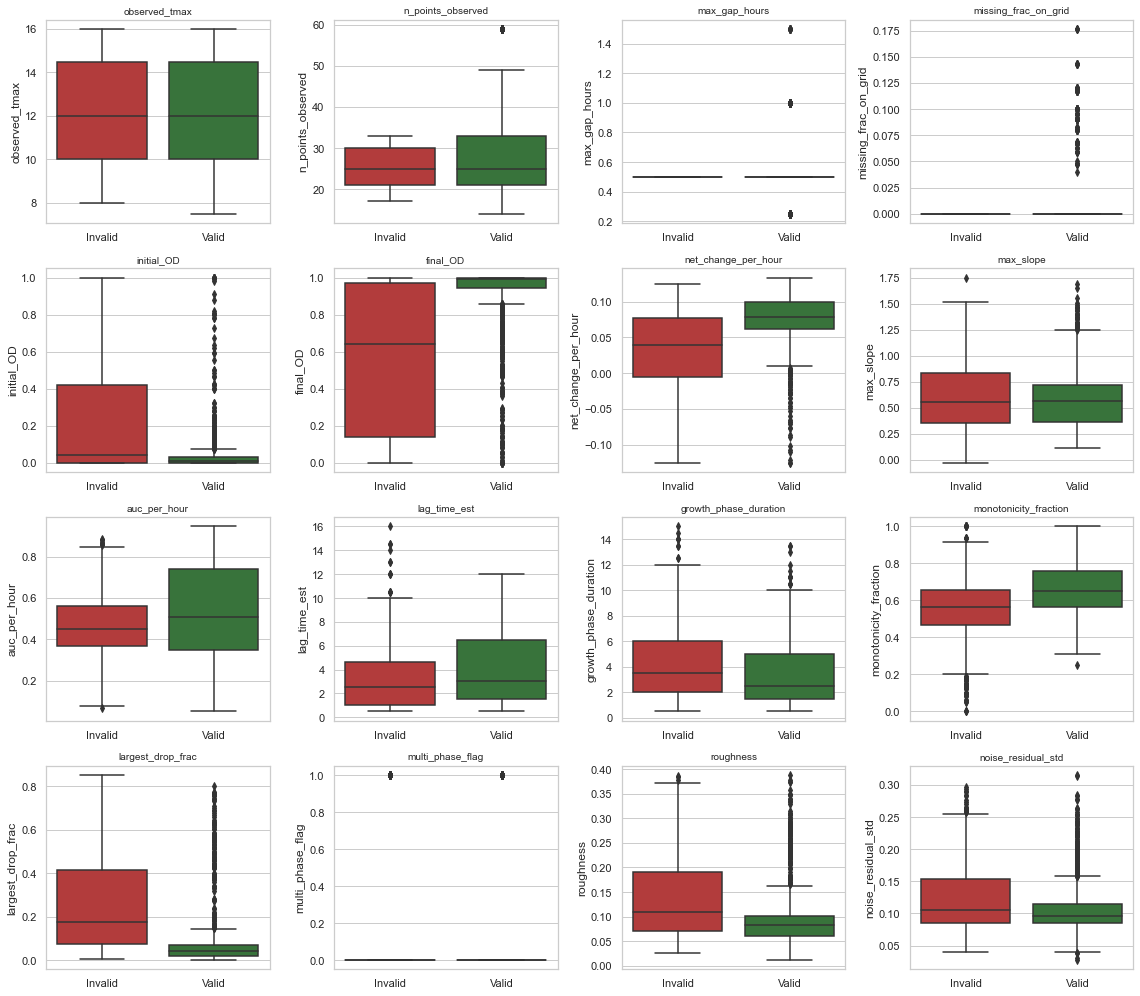

In [9]:
fig, axes = plt.subplots(4, 4, figsize=(16, 14))
labels = y_all.map({1: "Valid", 0: "Invalid"})
for ax, feat in zip(axes.flat, STAGE1_CANDIDATE_POOL):
    df_plot = pd.DataFrame({feat: X16[feat], "label": labels})
    sns.boxplot(
        data=df_plot,
        x="label",
        y=feat,
        ax=ax,
        palette={"Valid": "#2e7d32", "Invalid": "#c62828"},
    )
    ax.set_title(feat, fontsize=10)
    ax.set_xlabel("")
plt.tight_layout()
plt.show()


## 5. Correlation among the 16

A quick check that grouping the features conceptually also kept them numerically
distinct -- no pair here should be near 1.0.


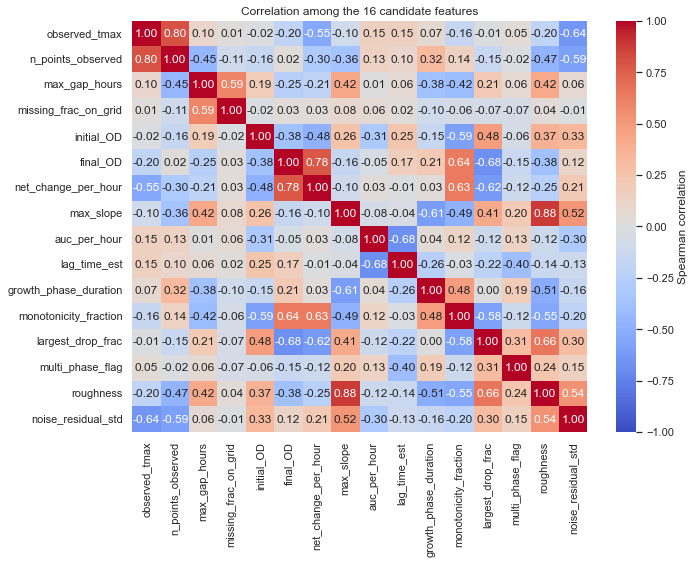

Highest pairwise correlations:
roughness            max_slope            0.881633
max_slope            roughness            0.881633
n_points_observed    observed_tmax        0.797615
observed_tmax        n_points_observed    0.797615
net_change_per_hour  final_OD             0.777087
dtype: float64


In [10]:
corr = X16.corr(method="spearman")
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=ax,
            cbar_kws={"label": "Spearman correlation"})
ax.set_title("Correlation among the 16 candidate features")
plt.tight_layout()
plt.show()

highest = corr.where(~np.eye(len(corr), dtype=bool)).abs().unstack().sort_values(ascending=False)
print("Highest pairwise correlations:")
print(highest.head(5))


## 6. Cross-validated feature ranking

One held-out test set is carved out first and not touched again until Section 7.
Everything in this section works on the remaining `trainval` data only, using grouped,
stratified K-fold CV so no curve's truncated variants leak across a fold.

Two independent rankings are produced:
- **Permutation importance**, averaged across folds -- how much does shuffling one
  feature hurt a model trained on all 16? Fast (one fit per fold) and stable.
- **Greedy forward selection**, repeated per fold -- which features get picked, and how
  often, when building a subset up one feature at a time? Slower, and known from
  earlier analysis to be less stable on a dataset this size, but it's the comparison
  method the thesis discusses, so it's reported alongside the ranking rather than
  instead of it.


In [11]:
idx = np.arange(len(X16))
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
trainval_idx, test_idx = next(gss.split(idx, y_all, groups_all))

overlap = set(groups_all.iloc[trainval_idx]) & set(groups_all.iloc[test_idx])
assert not overlap
print("trainval:", len(trainval_idx), "rows |", groups_all.iloc[trainval_idx].nunique(), "base curves")
print("test:    ", len(test_idx), "rows |", groups_all.iloc[test_idx].nunique(), "base curves")


trainval: 2379 rows | 793 base curves
test:     597 rows | 199 base curves


In [12]:
y_trainval = y_all.iloc[trainval_idx]
groups_trainval = groups_all.iloc[trainval_idx]
skf = StratifiedGroupKFold(n_splits=N_CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

importances_by_fold = []
for fold_train_rel, fold_val_rel in skf.split(trainval_idx, y_trainval, groups_trainval):
    fold_train_idx = trainval_idx[fold_train_rel]
    fold_val_idx = trainval_idx[fold_val_rel]

    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", RandomForestClassifier(n_estimators=RF_N_ESTIMATORS, random_state=RANDOM_STATE,
                                        class_weight="balanced_subsample", n_jobs=-1)),
    ])
    pipe.fit(X16.iloc[fold_train_idx], y_all.iloc[fold_train_idx])
    result = permutation_importance(
        pipe, X16.iloc[fold_val_idx], y_all.iloc[fold_val_idx],
        n_repeats=10, random_state=RANDOM_STATE, scoring="balanced_accuracy",
    )
    importances_by_fold.append(result.importances_mean)

importance_df = pd.DataFrame(importances_by_fold, columns=STAGE1_CANDIDATE_POOL)
ranking = importance_df.mean().sort_values(ascending=False)
ranking_std = importance_df.std()

print("Mean permutation importance across folds (higher = more useful):")
ranking


Mean permutation importance across folds (higher = more useful):


largest_drop_frac        0.166907
multi_phase_flag         0.016057
growth_phase_duration    0.015149
max_slope                0.014412
auc_per_hour             0.011553
lag_time_est             0.004938
max_gap_hours            0.003564
final_OD                 0.003326
net_change_per_hour      0.002593
roughness                0.002542
initial_OD               0.001679
missing_frac_on_grid     0.001619
monotonicity_fraction    0.000182
observed_tmax           -0.002188
n_points_observed       -0.002347
noise_residual_std      -0.003450
dtype: float64

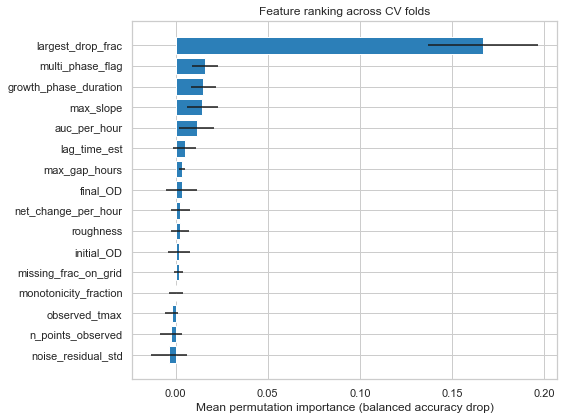

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))
order = ranking.index
ax.barh(order, ranking.values, xerr=ranking_std.reindex(order).values, color="#2c7fb8")
ax.invert_yaxis()
ax.set_xlabel("Mean permutation importance (balanced accuracy drop)")
ax.set_title("Feature ranking across CV folds")
plt.tight_layout()
plt.show()


In [14]:
def quick_rf_score(feats, train_idx_, val_idx_):
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", RandomForestClassifier(n_estimators=RF_PROXY_N_ESTIMATORS, random_state=RANDOM_STATE,
                                        class_weight="balanced_subsample", n_jobs=-1)),
    ])
    pipe.fit(X16[feats].iloc[train_idx_], y_all.iloc[train_idx_])
    pred = pipe.predict(X16[feats].iloc[val_idx_])
    return balanced_accuracy_score(y_all.iloc[val_idx_], pred)

def greedy_forward_selection(train_idx_, val_idx_):
    selected, remaining, history = [], list(STAGE1_CANDIDATE_POOL), []
    for step in range(GREEDY_MAX_STEPS):
        best_feat, best_score = None, -1.0
        for f in remaining:
            s = quick_rf_score(selected + [f], train_idx_, val_idx_)
            if s > best_score:
                best_score, best_feat = s, f
        prev = history[-1][1] if history else 0.0
        if best_score - prev < GREEDY_PLATEAU_GAIN and step >= 3:
            break
        selected.append(best_feat); remaining.remove(best_feat)
        history.append((best_feat, best_score))
    return selected

fold_selections = []
for fold_train_rel, fold_val_rel in skf.split(trainval_idx, y_trainval, groups_trainval):
    fold_train_idx = trainval_idx[fold_train_rel]
    fold_val_idx = trainval_idx[fold_val_rel]
    selected = greedy_forward_selection(fold_train_idx, fold_val_idx)
    fold_selections.append(selected)
    print("fold selected:", selected)


fold selected: ['final_OD', 'n_points_observed', 'largest_drop_frac', 'max_slope', 'auc_per_hour', 'max_gap_hours']
fold selected: ['largest_drop_frac', 'final_OD', 'auc_per_hour', 'net_change_per_hour', 'lag_time_est', 'multi_phase_flag', 'missing_frac_on_grid', 'max_gap_hours']
fold selected: ['final_OD', 'largest_drop_frac', 'max_slope', 'auc_per_hour', 'lag_time_est', 'growth_phase_duration', 'missing_frac_on_grid', 'initial_OD']
fold selected: ['largest_drop_frac', 'final_OD', 'max_slope', 'multi_phase_flag', 'observed_tmax']
fold selected: ['final_OD', 'roughness', 'multi_phase_flag', 'largest_drop_frac', 'max_slope', 'auc_per_hour', 'max_gap_hours']


In [15]:
from collections import Counter
vote_count = Counter(f for sel in fold_selections for f in sel)
greedy_stability = pd.DataFrame(
    [{"feature": f, "n_folds_selected": vote_count.get(f, 0)} for f in STAGE1_CANDIDATE_POOL]
).sort_values("n_folds_selected", ascending=False).reset_index(drop=True)

GREEDY_SUBSET = greedy_stability.loc[
    greedy_stability["n_folds_selected"] > N_CV_FOLDS / 2, "feature"
].tolist()

print(f"Greedy CV-stable subset ({len(GREEDY_SUBSET)} features, selected in a majority of {N_CV_FOLDS} folds):")
print(GREEDY_SUBSET)
greedy_stability


Greedy CV-stable subset (6 features, selected in a majority of 5 folds):
['final_OD', 'largest_drop_frac', 'max_slope', 'auc_per_hour', 'max_gap_hours', 'multi_phase_flag']


,feature,n_folds_selected
0,final_OD,5
1,largest_drop_frac,5
2,max_slope,4
3,auc_per_hour,4
4,max_gap_hours,3
5,multi_phase_flag,3
6,missing_frac_on_grid,2
7,lag_time_est,2
8,observed_tmax,1
9,n_points_observed,1


## 7. Final comparison: one honest look at the held-out test set

Everything above used only `trainval`. Four feature sets are now each trained once on
the full `trainval` data and scored once on `test` -- the only test-set number in this
notebook, so it isn't optimistically biased by having been reused across selection
decisions.


In [38]:
TOP_8 = ranking.index[:8].tolist()
TOP_10 = ranking.index[:10].tolist()

print("FULL:  ", STAGE1_CANDIDATE_POOL)
print("TOP_8: ", TOP_8)
print("TOP_10:", TOP_10)
print("GREEDY:", GREEDY_SUBSET)
FINAL_8: ['observed_tmax', 'net_change_per_hour', 'max_slope', 'lag_time_est', 'monotonicity_fraction', 'largest_drop_frac', 'roughness', 'final_to_peak_ratio']
TOP_8:  ['largest_drop_frac', 'multi_phase_flag', 'growth_phase_duration', 'max_slope', 'auc_per_hour', 'lag_time_est', 'max_gap_hours', 'final_OD']

# growth_dynamics : max_slope', 'lag_time_est, net_change_per_hour, growth_phase_duration ( 3 each)
# shape_integrity : largest_drop_frac, 
# observation_quality : observed_tmax , max_gap_hours (1 each)
# level : final_OD


FULL:   ['observed_tmax', 'n_points_observed', 'max_gap_hours', 'missing_frac_on_grid', 'initial_OD', 'final_OD', 'net_change_per_hour', 'max_slope', 'auc_per_hour', 'lag_time_est', 'growth_phase_duration', 'monotonicity_fraction', 'largest_drop_frac', 'multi_phase_flag', 'roughness', 'noise_residual_std']
TOP_8:  ['largest_drop_frac', 'multi_phase_flag', 'growth_phase_duration', 'max_slope', 'auc_per_hour', 'lag_time_est', 'max_gap_hours', 'final_OD']
TOP_10: ['largest_drop_frac', 'multi_phase_flag', 'growth_phase_duration', 'max_slope', 'auc_per_hour', 'lag_time_est', 'max_gap_hours', 'final_OD', 'net_change_per_hour', 'roughness']
GREEDY: ['final_OD', 'largest_drop_frac', 'max_slope', 'auc_per_hour', 'max_gap_hours', 'multi_phase_flag']


In [17]:
def evaluate_on_holdout(feats, name):
    Xs = X16[feats]
    rows = []
    for model_name, pipe in build_models().items():
        pipe.fit(Xs.iloc[trainval_idx], y_all.iloc[trainval_idx])
        pred = pipe.predict(Xs.iloc[test_idx])
        proba = pipe.predict_proba(Xs.iloc[test_idx])[:, 1]
        rows.append({
            "feature_set": name, "n_features": len(feats), "model": model_name,
            "balanced_acc": balanced_accuracy_score(y_all.iloc[test_idx], pred),
            "f1": f1_score(y_all.iloc[test_idx], pred),
            "roc_auc": roc_auc_score(y_all.iloc[test_idx], proba),
        })
    return pd.DataFrame(rows)

final_results = pd.concat([
    evaluate_on_holdout(STAGE1_CANDIDATE_POOL, "FULL (16)"),
    evaluate_on_holdout(TOP_10, "TOP_10"),
    evaluate_on_holdout(TOP_8, "TOP_8"),
    evaluate_on_holdout(GREEDY_SUBSET, "GREEDY (CV-stable)"),
], ignore_index=True)

pivot = final_results.pivot_table(index="feature_set", columns="model",
                                   values=["balanced_acc", "f1", "roc_auc"]).round(4)
pivot = pivot.reindex(["FULL (16)", "TOP_10", "TOP_8", "GREEDY (CV-stable)"])
pivot


balanced_acc                      f1                  \
model                       HGB      LR      RF     HGB      LR      RF   
feature_set                                                               
FULL (16)                0.8278  0.7977  0.8336  0.8632  0.8180  0.8669   
TOP_10                   0.8185  0.8038  0.8342  0.8510  0.8464  0.8637   
TOP_8                    0.8214  0.8033  0.8234  0.8543  0.8468  0.8584   
GREEDY (CV-stable)       0.8303  0.7994  0.8180  0.8584  0.8415  0.8543   

                   roc_auc                  
model                  HGB      LR      RF  
feature_set                                 
FULL (16)           0.9333  0.8944  0.9343  
TOP_10              0.9206  0.8449  0.9242  
TOP_8               0.9229  0.8422  0.9233  
GREEDY (CV-stable)  0.9144  0.8494  0.9069

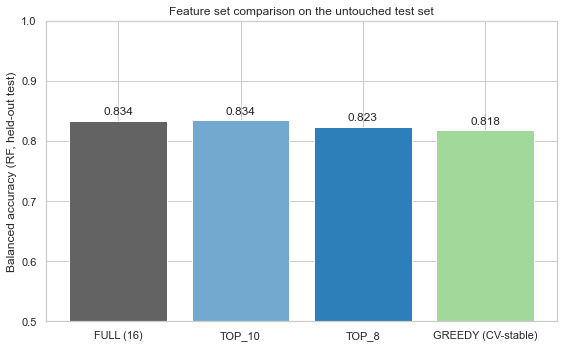

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))
plot_df = final_results[final_results.model == "RF"].set_index("feature_set")
plot_df = plot_df.reindex(["FULL (16)", "TOP_10", "TOP_8", "GREEDY (CV-stable)"])
ax.bar(plot_df.index, plot_df["balanced_acc"], color=["#636363", "#74a9cf", "#2c7fb8", "#a1d99b"])
ax.set_ylim(0.5, 1.0)
ax.set_ylabel("Balanced accuracy (RF, held-out test)")
ax.set_title("Feature set comparison on the untouched test set")
for i, v in enumerate(plot_df["balanced_acc"]):
    ax.text(i, v + 0.01, f"{v:.3f}", ha="center")
plt.tight_layout()
plt.show()


## 8. Save results for the thesis

Everything a chapter draft would need to cite: the separability table, the correlation
matrix, the CV ranking, the greedy-selection stability table, and the final comparison.


In [19]:
OUT_DIR = Path("classifier_output_feature_analysis")
OUT_DIR.mkdir(exist_ok=True)

separability.to_csv(OUT_DIR / "feature_separability.csv", index=False)
corr.to_csv(OUT_DIR / "feature_correlation_matrix.csv")
ranking.to_frame("mean_permutation_importance").to_csv(OUT_DIR / "cv_feature_ranking.csv")
greedy_stability.to_csv(OUT_DIR / "greedy_selection_stability.csv", index=False)
final_results.to_csv(OUT_DIR / "final_holdout_comparison.csv", index=False)

print("Wrote:")
for p in sorted(OUT_DIR.glob("*.csv")):
    print(" -", p)


Wrote:
 - classifier_output_feature_analysis\cv_feature_ranking.csv
 - classifier_output_feature_analysis\feature_correlation_matrix.csv
 - classifier_output_feature_analysis\feature_separability.csv
 - classifier_output_feature_analysis\final_holdout_comparison.csv
 - classifier_output_feature_analysis\greedy_selection_stability.csv


## Summary

- Section 2 gives the exact synthetic-dataset composition and example curves per
  subtype -- straight into the "training data" part of the chapter.
- Section 4's table and grid of plots show which features separate the classes on
  their own, and by how much.
- Section 6 gives two independent views of feature importance (permutation ranking and
  greedy CV stability); where they agree is the strongest evidence for a feature's
  inclusion, where they disagree is worth a sentence of honest discussion.
- Section 7 is the one number to actually quote: whichever set wins there, on data none
  of the earlier steps got to see, is the defensible choice for
  `STAGE1_SELECTED_FEATURES`.


In [25]:
import json 
ART_DIR = Path("classifier_output_notebook_run")
train_out = train_from_meta_csv(
    meta_csv=META_CSV,
    art_dir=ART_DIR,
    run_tag="stage1_feature",
    write_lockfile=False,
    selected_features=TOP_8,
)
print(json.dumps({k: v for k, v in train_out.items() if k not in ("feature_columns",)}, indent=2))

{
  "run_tag": "stage1_feature",
  "meta_csv": "..\\data\\train_data\\training_meta.csv",
  "label_col": "Is_Valid",
  "feature_count": 8,
  "group_split_col": "base_curve_id",
  "model_paths": {
    "LR": "classifier_output_notebook_run\\LR_selected_pipeline_stage1_feature.joblib",
    "RF": "classifier_output_notebook_run\\RF_selected_pipeline_stage1_feature.joblib",
    "HGB": "classifier_output_notebook_run\\HGB_selected_pipeline_stage1_feature.joblib"
  },
  "manifest_paths": {
    "LR": "classifier_output_notebook_run\\LR_selected_pipeline_stage1_feature.manifest.json",
    "RF": "classifier_output_notebook_run\\RF_selected_pipeline_stage1_feature.manifest.json",
    "HGB": "classifier_output_notebook_run\\HGB_selected_pipeline_stage1_feature.manifest.json"
  },
  "selected_features_path": "classifier_output_notebook_run\\selected_features_stage1_feature.json",
  "thresholds_path": "classifier_output_notebook_run\\thresholds_stage1_feature.json",
  "results_path": "classifier_out

In [27]:
import sys
sys.path.insert(0, "src")
from growthqa.pipelines.infer_labels import run_label_inference_from_uploaded_wide

class Settings:
    input_is_raw = False
    step = 0.25
    min_points = 3
    low_res_threshold = 7
    tmax_hours = 16.0
    auto_tmax = False
    auto_tmax_coverage = 0.8
    clip_negatives = False
    global_blank = None
    smooth_method = "SGF"
    smooth_window = 5
    normalize = "MINMAX"

MODEL_DIR = str(ART_DIR)

demo_lab = pd.read_csv("../data/test_data/lab/16h_0.25_lab.csv")
demo_beyond16h = pd.read_csv("../data/test_data/synthetic/20h.csv")

for demo_df, tag in [(demo_lab, "lab_16h_0.25_Sparse_Extr"), (demo_beyond16h, "test_curves_tmax20h")]:
    if "FileName" not in demo_df.columns:
        demo_df["FileName"] = tag
    if "Model Name" not in demo_df.columns:
        demo_df["Model Name"] = "Uploaded"
    if "Is_Valid" not in demo_df.columns:
        demo_df["Is_Valid"] = True

out_lab = run_label_inference_from_uploaded_wide(
    wide_df=demo_lab, settings=Settings(), model_dir=MODEL_DIR,
    model_name="Average", stage2_start=16.0,
)
out_b16 = run_label_inference_from_uploaded_wide(
    wide_df=demo_beyond16h, settings=Settings(), model_dir=MODEL_DIR,
    model_name="Average", stage2_start=16.0,
)

print("=== lab_16h_0.25_Sparse_Extr.csv (7 lab curves, <= 16h) ===")
print(out_lab["out_df"]["Stage 2 Label"].value_counts())
print(out_lab["out_df"]["final_label"].value_counts())
print()
print("=== test_curves_tmax20h.csv (8 synthetic curves, extend to 20h) ===")
print(out_b16["out_df"]["Stage 2 Label"].value_counts())
print(out_b16["out_df"]["final_label"].value_counts())

=== lab_16h_0.25_Sparse_Extr.csv (7 lab curves, <= 16h) ===
Insufficient    7
Name: Stage 2 Label, dtype: int64
Valid    7
Name: final_label, dtype: int64

=== test_curves_tmax20h.csv (8 synthetic curves, extend to 20h) ===
Corroborated     7
Contradiction    1
Name: Stage 2 Label, dtype: int64
Valid      5
Invalid    2
Unsure     1
Name: final_label, dtype: int64


In [28]:
cols = ["Test Id", "Pred Label", "S1 Confidence Valid", "Stage 2 Label", "Label Reason", "final_label"]
print("Sample of the >16h demo predictions (Stage 2 evidence engaged):")
out_b16["out_df"][cols].head(12)

Sample of the >16h demo predictions (Stage 2 evidence engaged):


,Test Id,Pred Label,S1 Confidence Valid,Stage 2 Label,Label Reason,final_label
0,L01,Valid,0.9376,Corroborated,S2_STABLE_OR_PLATEAU,Valid
1,L02,Valid,0.9348,Corroborated,S2_STABLE_OR_PLATEAU,Valid
2,L03,Invalid,0.0538,Corroborated,S2_CORROBORATES_INVALID,Invalid
3,L04,Invalid,0.1188,Corroborated,S2_CORROBORATES_INVALID,Invalid
4,L05,Valid,0.9437,Contradiction,S2_LATE_DECLINE_DETECTED: Confidence(Valid) = ...,Unsure
5,L06,Valid,0.8910,Corroborated,S2_STABLE_OR_PLATEAU,Valid
6,L07,Valid,0.8904,Corroborated,S2_STABLE_OR_PLATEAU,Valid
7,L08,Valid,0.6880,Corroborated,S2_STABLE_OR_PLATEAU,Valid


In [29]:
import json 
ART_DIR = Path("classifier_output_notebook_run_10")
train_out = train_from_meta_csv(
    meta_csv=META_CSV,
    art_dir=ART_DIR,
    run_tag="stage1_feature",
    write_lockfile=False,
    selected_features=TOP_10,
)
print(json.dumps({k: v for k, v in train_out.items() if k not in ("feature_columns",)}, indent=2))

{
  "run_tag": "stage1_feature",
  "meta_csv": "..\\data\\train_data\\training_meta.csv",
  "label_col": "Is_Valid",
  "feature_count": 10,
  "group_split_col": "base_curve_id",
  "model_paths": {
    "LR": "classifier_output_notebook_run_10\\LR_selected_pipeline_stage1_feature.joblib",
    "RF": "classifier_output_notebook_run_10\\RF_selected_pipeline_stage1_feature.joblib",
    "HGB": "classifier_output_notebook_run_10\\HGB_selected_pipeline_stage1_feature.joblib"
  },
  "manifest_paths": {
    "LR": "classifier_output_notebook_run_10\\LR_selected_pipeline_stage1_feature.manifest.json",
    "RF": "classifier_output_notebook_run_10\\RF_selected_pipeline_stage1_feature.manifest.json",
    "HGB": "classifier_output_notebook_run_10\\HGB_selected_pipeline_stage1_feature.manifest.json"
  },
  "selected_features_path": "classifier_output_notebook_run_10\\selected_features_stage1_feature.json",
  "thresholds_path": "classifier_output_notebook_run_10\\thresholds_stage1_feature.json",
  "resul

In [30]:
import sys
sys.path.insert(0, "src")
from growthqa.pipelines.infer_labels import run_label_inference_from_uploaded_wide

class Settings:
    input_is_raw = False
    step = 0.25
    min_points = 3
    low_res_threshold = 7
    tmax_hours = 16.0
    auto_tmax = False
    auto_tmax_coverage = 0.8
    clip_negatives = False
    global_blank = None
    smooth_method = "SGF"
    smooth_window = 5
    normalize = "MINMAX"

MODEL_DIR = str(ART_DIR)

demo_lab = pd.read_csv("../data/test_data/lab/16h_0.25_lab.csv")
demo_beyond16h = pd.read_csv("../data/test_data/synthetic/20h.csv")

for demo_df, tag in [(demo_lab, "lab_16h_0.25_Sparse_Extr"), (demo_beyond16h, "test_curves_tmax20h")]:
    if "FileName" not in demo_df.columns:
        demo_df["FileName"] = tag
    if "Model Name" not in demo_df.columns:
        demo_df["Model Name"] = "Uploaded"
    if "Is_Valid" not in demo_df.columns:
        demo_df["Is_Valid"] = True

out_lab = run_label_inference_from_uploaded_wide(
    wide_df=demo_lab, settings=Settings(), model_dir=MODEL_DIR,
    model_name="Average", stage2_start=16.0,
)
out_b16 = run_label_inference_from_uploaded_wide(
    wide_df=demo_beyond16h, settings=Settings(), model_dir=MODEL_DIR,
    model_name="Average", stage2_start=16.0,
)

print("=== lab_16h_0.25_Sparse_Extr.csv (7 lab curves, <= 16h) ===")
print(out_lab["out_df"]["Stage 2 Label"].value_counts())
print(out_lab["out_df"]["final_label"].value_counts())
print()
print("=== test_curves_tmax20h.csv (8 synthetic curves, extend to 20h) ===")
print(out_b16["out_df"]["Stage 2 Label"].value_counts())
print(out_b16["out_df"]["final_label"].value_counts())

=== lab_16h_0.25_Sparse_Extr.csv (7 lab curves, <= 16h) ===
Insufficient    7
Name: Stage 2 Label, dtype: int64
Valid    7
Name: final_label, dtype: int64

=== test_curves_tmax20h.csv (8 synthetic curves, extend to 20h) ===
Corroborated     7
Contradiction    1
Name: Stage 2 Label, dtype: int64
Valid      5
Invalid    2
Unsure     1
Name: final_label, dtype: int64


In [31]:
cols = ["Test Id", "Pred Label", "S1 Confidence Valid", "Stage 2 Label", "Label Reason", "final_label"]
print("Sample of the >16h demo predictions (Stage 2 evidence engaged):")
out_b16["out_df"][cols].head(12)

Sample of the >16h demo predictions (Stage 2 evidence engaged):


,Test Id,Pred Label,S1 Confidence Valid,Stage 2 Label,Label Reason,final_label
0,L01,Valid,0.9060,Corroborated,S2_STABLE_OR_PLATEAU,Valid
1,L02,Valid,0.8964,Corroborated,S2_STABLE_OR_PLATEAU,Valid
2,L03,Invalid,0.0607,Corroborated,S2_CORROBORATES_INVALID,Invalid
3,L04,Invalid,0.1782,Corroborated,S2_CORROBORATES_INVALID,Invalid
4,L05,Valid,0.9234,Contradiction,S2_LATE_DECLINE_DETECTED: Confidence(Valid) = ...,Unsure
5,L06,Valid,0.8383,Corroborated,S2_STABLE_OR_PLATEAU,Valid
6,L07,Valid,0.8410,Corroborated,S2_STABLE_OR_PLATEAU,Valid
7,L08,Valid,0.5697,Corroborated,S2_STABLE_OR_PLATEAU,Valid


In [34]:
import json 
ART_DIR = Path("classifier_output_notebook_run_Greedy")
train_out = train_from_meta_csv(
    meta_csv=META_CSV,
    art_dir=ART_DIR,
    run_tag="stage1_feature",
    write_lockfile=False,
    selected_features=GREEDY_SUBSET,
)
print(json.dumps({k: v for k, v in train_out.items() if k not in ("feature_columns",)}, indent=2))

{
  "run_tag": "stage1_feature",
  "meta_csv": "..\\data\\train_data\\training_meta.csv",
  "label_col": "Is_Valid",
  "feature_count": 6,
  "group_split_col": "base_curve_id",
  "model_paths": {
    "LR": "classifier_output_notebook_run_Greedy\\LR_selected_pipeline_stage1_feature.joblib",
    "RF": "classifier_output_notebook_run_Greedy\\RF_selected_pipeline_stage1_feature.joblib",
    "HGB": "classifier_output_notebook_run_Greedy\\HGB_selected_pipeline_stage1_feature.joblib"
  },
  "manifest_paths": {
    "LR": "classifier_output_notebook_run_Greedy\\LR_selected_pipeline_stage1_feature.manifest.json",
    "RF": "classifier_output_notebook_run_Greedy\\RF_selected_pipeline_stage1_feature.manifest.json",
    "HGB": "classifier_output_notebook_run_Greedy\\HGB_selected_pipeline_stage1_feature.manifest.json"
  },
  "selected_features_path": "classifier_output_notebook_run_Greedy\\selected_features_stage1_feature.json",
  "thresholds_path": "classifier_output_notebook_run_Greedy\\thresholds

In [35]:
import sys
sys.path.insert(0, "src")
from growthqa.pipelines.infer_labels import run_label_inference_from_uploaded_wide

class Settings:
    input_is_raw = False
    step = 0.25
    min_points = 3
    low_res_threshold = 7
    tmax_hours = 16.0
    auto_tmax = False
    auto_tmax_coverage = 0.8
    clip_negatives = False
    global_blank = None
    smooth_method = "SGF"
    smooth_window = 5
    normalize = "MINMAX"

MODEL_DIR = str(ART_DIR)

demo_lab = pd.read_csv("../data/test_data/lab/16h_0.25_lab.csv")
demo_beyond16h = pd.read_csv("../data/test_data/synthetic/20h.csv")

for demo_df, tag in [(demo_lab, "lab_16h_0.25_Sparse_Extr"), (demo_beyond16h, "test_curves_tmax20h")]:
    if "FileName" not in demo_df.columns:
        demo_df["FileName"] = tag
    if "Model Name" not in demo_df.columns:
        demo_df["Model Name"] = "Uploaded"
    if "Is_Valid" not in demo_df.columns:
        demo_df["Is_Valid"] = True

out_lab = run_label_inference_from_uploaded_wide(
    wide_df=demo_lab, settings=Settings(), model_dir=MODEL_DIR,
    model_name="Average", stage2_start=16.0,
)
out_b16 = run_label_inference_from_uploaded_wide(
    wide_df=demo_beyond16h, settings=Settings(), model_dir=MODEL_DIR,
    model_name="Average", stage2_start=16.0,
)

print("=== lab_16h_0.25_Sparse_Extr.csv (7 lab curves, <= 16h) ===")
print(out_lab["out_df"]["Stage 2 Label"].value_counts())
print(out_lab["out_df"]["final_label"].value_counts())
print()
print("=== test_curves_tmax20h.csv (8 synthetic curves, extend to 20h) ===")
print(out_b16["out_df"]["Stage 2 Label"].value_counts())
print(out_b16["out_df"]["final_label"].value_counts())

=== lab_16h_0.25_Sparse_Extr.csv (7 lab curves, <= 16h) ===
Insufficient    7
Name: Stage 2 Label, dtype: int64
Valid    7
Name: final_label, dtype: int64

=== test_curves_tmax20h.csv (8 synthetic curves, extend to 20h) ===
Corroborated     7
Contradiction    1
Name: Stage 2 Label, dtype: int64
Valid      5
Invalid    2
Unsure     1
Name: final_label, dtype: int64


In [36]:
cols = ["Test Id", "Pred Label", "S1 Confidence Valid", "Stage 2 Label", "Label Reason", "final_label"]
print("Sample of the >16h demo predictions (Stage 2 evidence engaged):")
out_b16["out_df"][cols].head(12)

Sample of the >16h demo predictions (Stage 2 evidence engaged):


,Test Id,Pred Label,S1 Confidence Valid,Stage 2 Label,Label Reason,final_label
0,L01,Valid,0.9188,Corroborated,S2_STABLE_OR_PLATEAU,Valid
1,L02,Valid,0.9164,Corroborated,S2_STABLE_OR_PLATEAU,Valid
2,L03,Invalid,0.0788,Corroborated,S2_CORROBORATES_INVALID,Invalid
3,L04,Invalid,0.1966,Corroborated,S2_CORROBORATES_INVALID,Invalid
4,L05,Valid,0.8952,Contradiction,S2_LATE_DECLINE_DETECTED: Confidence(Valid) = ...,Unsure
5,L06,Valid,0.8937,Corroborated,S2_STABLE_OR_PLATEAU,Valid
6,L07,Valid,0.9124,Corroborated,S2_STABLE_OR_PLATEAU,Valid
7,L08,Valid,0.6859,Corroborated,S2_STABLE_OR_PLATEAU,Valid
